<a href="https://colab.research.google.com/github/Samu24042/CienciaDeDatos/blob/main/TALLER_Hipotesis_Gauss_Reg_Log.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TALLER
## 1. Importar datos de estatura peso y sexo de individuos.


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm

df = pd.read_csv("weight-height.csv",
    usecols=["Height", "Weight", "Gender"])

print("--- Valores nulos por columna ---")
print(df.isna().sum())

display(df.head())

--- Valores nulos por columna ---
Height    0
Weight    0
Gender    0
dtype: int64


,Height,Weight,Gender
0,161.72,53.80,Female
1,171.99,76.12,Male
2,179.51,87.38,Male
3,179.68,74.28,Male
4,162.94,62.76,Female


## 2. Visualizar los datos y las distribuciones

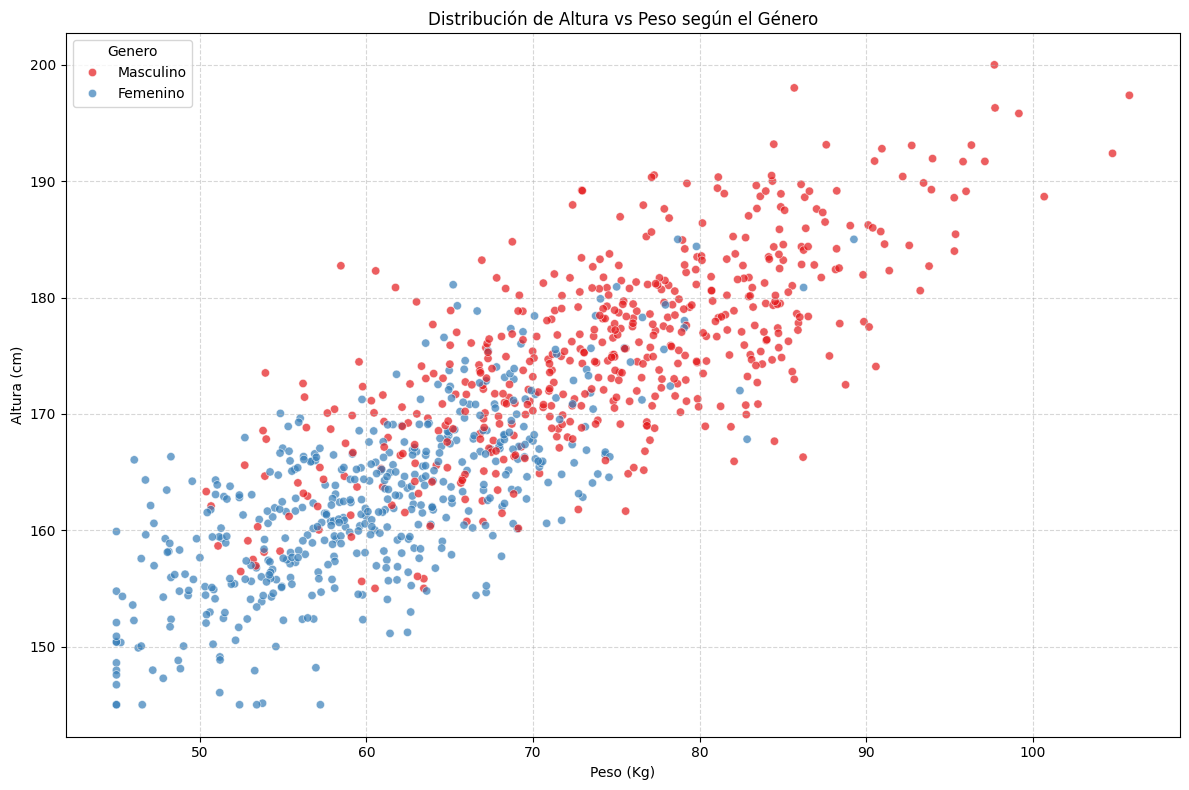

In [127]:
# =====================================================================
# Visusalizacion
# =====================================================================
df_sampled = df.sample(n=1000, random_state=42)
df_sampled['Gender'] = df_sampled['Gender'].replace({
    'Male': 'Masculino',
    'Female': 'Femenino'
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x ='Weight',
    y ='Height',
    hue ='Gender',
    data = df_sampled,
    palette='Set1',
    alpha=0.7
)

# Configuraciones del gráfico
plt.title('Distribución de Altura vs Peso según el Género')
plt.xlabel(f'Peso (Kg)')
plt.ylabel(f'Altura (cm)')
plt.legend(title='Genero')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 3. Aplicar PCA para encontrar una variable de tamaño corporal

In [128]:
variables = ['Height', 'Weight']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[variables])

pca = PCA(n_components=1)
body_size = pca.fit_transform(X_scaled)
df['Body_Size'] = body_size

normalizador = MinMaxScaler(feature_range=(0,100))
df['Body_Size'] = normalizador.fit_transform(body_size)

df['Body_Category'] = pd.cut(
    df['Body_Size'],
    bins=[0,33,66,100],
    labels=['Pequeño','Mediano','Grande']
)



print(pca.explained_variance_ratio_[0] * 100)
print(pca.components_)

display(df.head())



91.09955870582974
[[0.70710678 0.70710678]]


,Height,Weight,Gender,Body_Size,Body_Category
0,161.72,53.80,Female,21.805912,Pequeño
1,171.99,76.12,Male,48.490541,Mediano
2,179.51,87.38,Male,64.035585,Mediano
3,179.68,74.28,Male,53.893719,Mediano
4,162.94,62.76,Female,29.932766,Pequeño


## 4. Visualizar las pdf sobre la nueva variable

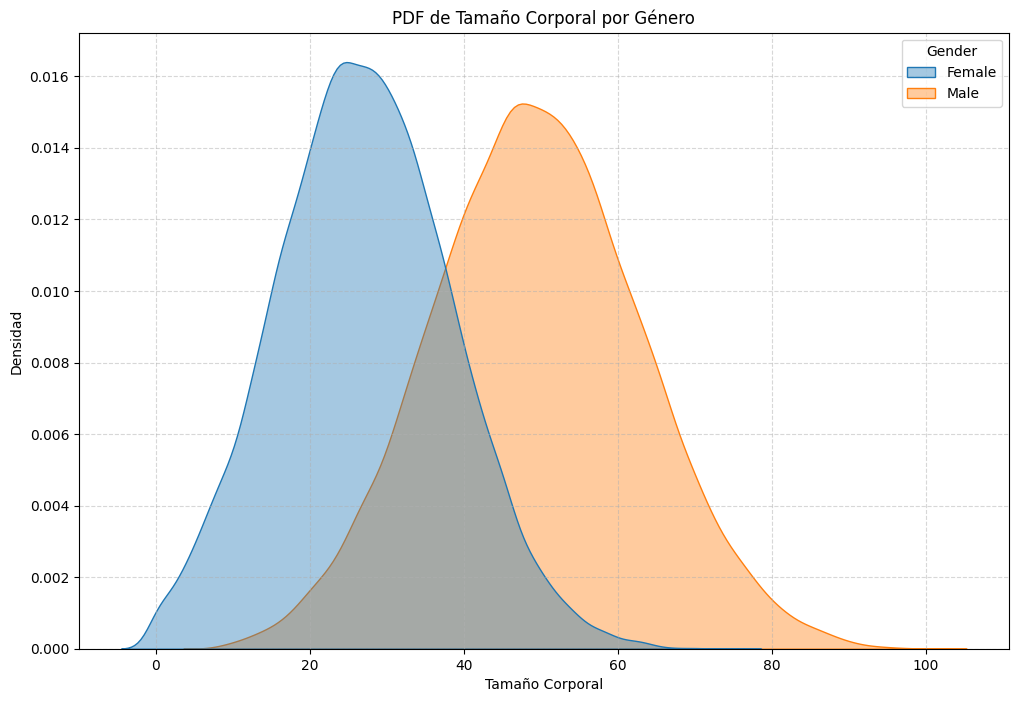

In [129]:
plt.figure(figsize=(12,8))
sns.kdeplot(
    data=df,
    x='Body_Size',
    hue='Gender',
    fill=True,
    alpha=0.4
)

plt.title('PDF de Tamaño Corporal por Género')
plt.xlabel('Tamaño Corporal')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


## 5. Aplicar una prueba de hipotesis gaussiana

In [130]:
male = df[df['Gender']=='Male']['Body_Size']
female = df[df['Gender']=='Female']['Body_Size']

mu_m = male.mean()
sigma_m = male.std()

mu_f = female.mean()
sigma_f = female.std()

# Predicciones gaussianas
y_pred_gauss = []

for x in X_test['Body_Size']:

    p_male = norm.pdf(x, mu_m, sigma_m)
    p_female = norm.pdf(x, mu_f, sigma_f)
    cociente_verosimilitud = p_male/p_female

    if cociente_verosimilitud > 1:
        y_pred_gauss.append(1)  # Hombre
    else:
        y_pred_gauss.append(0)  # Mujer

y_pred_gauss = np.array(y_pred_gauss)

acc_gauss = accuracy_score(y_test, y_pred_gauss)
cm_gauss = confusion_matrix(y_test, y_pred_gauss)

print(cm_gauss)
print(f"Accuracy Gaussiano: {acc_gauss:.4f}")

[[5980 1164]
 [1679 6177]]
Accuracy Gaussiano: 0.8105


## 6. Aplicar una regresion logistica

In [131]:
# =====================================================
# 6. Regresión Logística
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Convertir género a numérico
df['Gender_num'] = df['Gender'].map({
    'Female': 0,
    'Male': 1
})

# Variable predictora (Body_Size)
X = df[['Body_Size']]

# Variable objetivo (Gender)
y = df['Gender_num']

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Crear y entrenar modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Métricas
print("Accuracy Gaussiano:", accuracy_score(y_test, y_pred))

cm_log = confusion_matrix(y_test, y_pred)

print(cm_log)

Accuracy Gaussiano: 0.8104666666666667
[[5733 1411]
 [1432 6424]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


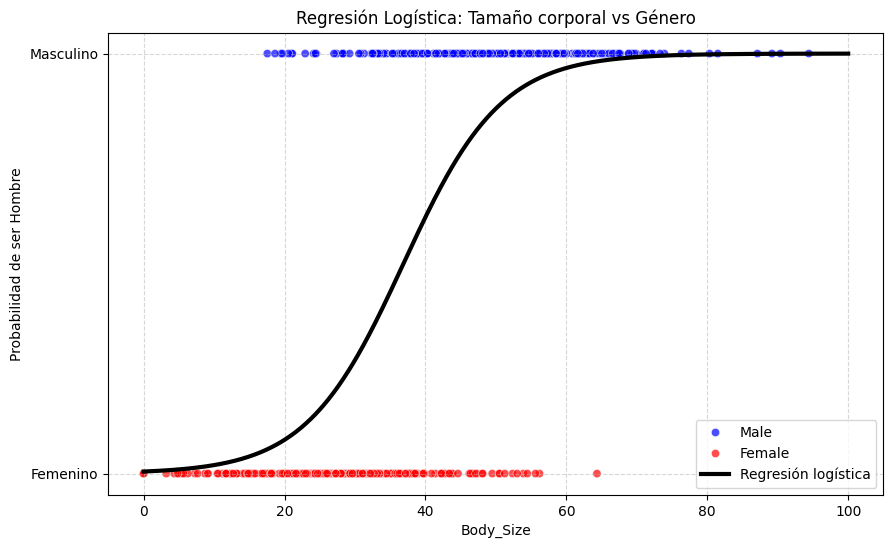

In [132]:
# Muestra de 500 datos
df_sample = df.sample(n=500, random_state=42)

# Rango para la curva logística
x_range = np.linspace(
    X['Body_Size'].min(),
    X['Body_Size'].max(),
    1000
).reshape(-1, 1)

prob = modelo.predict_proba(x_range)[:, 1]

plt.figure(figsize=(10,6))

# Puntos coloreados por género
sns.scatterplot(
    data=df_sample,
    x='Body_Size',
    y='Gender_num',
    hue='Gender',
    palette={'Male':'blue', 'Female':'red'},
    alpha=0.7
)

# Curva logística
plt.plot(
    x_range,
    prob,
    color='black',
    linewidth=3,
    label='Regresión logística'
)

plt.title('Regresión Logística: Tamaño corporal vs Género')
plt.xlabel('Body_Size')
plt.ylabel('Probabilidad de ser Hombre')

plt.yticks([0,1], ['Femenino', 'Masculino'])

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

## 7. Comparacion exactitud y matrices de confusion

In [133]:
acc_gauss = accuracy_score(y_test, y_pred_gauss)
acc_log = accuracy_score(y_test, y_pred)

print(f"Accuracy Gaussiano: {acc_gauss:.4f}")
print(f"Accuracy Logístico: {acc_log:.4f}")

Accuracy Gaussiano: 0.8105
Accuracy Logístico: 0.8105


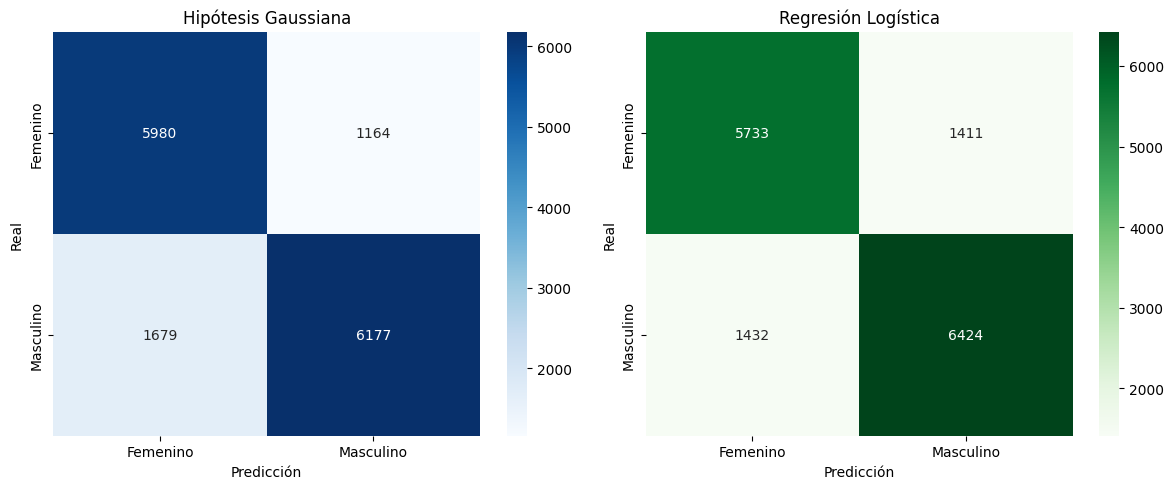

In [134]:

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(
    cm_gauss,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Femenino','Masculino'],
    yticklabels=['Femenino','Masculino'],
    ax=ax[0]
)

ax[0].set_title('Hipótesis Gaussiana')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Real')

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Femenino','Masculino'],
    yticklabels=['Femenino','Masculino'],
    ax=ax[1]
)

ax[1].set_title('Regresión Logística')
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Real')

plt.tight_layout()
plt.show()